# Assignment 2 (10th April)
Joanna Kusy 275999, Tomasz Srebniak 275987

## Problem 2.1: SHAP Analysis (30 points)
Train a Random Forest classifier on the Adult Income dataset:

• Calculate SHAP values for all test samples.

• Create summary plots, force plots, and dependence plots.

• Identify the top 5 most important features globally.

• Explain predictions for 3 specific individuals with different outcomes.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import shap  # shap analysis and adult income dataset

import ssl, certifi # Ensure that SSL certificates are properly handled for secure connections 
ssl._create_default_https_context = lambda: ssl.create_default_context(cafile=certifi.where())

import warnings
warnings.filterwarnings('ignore')

In [3]:
SEED = 42
np.random.seed(SEED)  # Set random seed for reproducibility

### Load the data

In [4]:
X_encoded, y = shap.datasets.adult()  # for modelling and shap values
print("Encoded features shape:", X_encoded.shape
      , "\nEncoded features columns:\n", X_encoded.columns.tolist()
      , "\nTarget variable shape:", y.shape
      , "\nUnique target classes:", np.unique(y)
      , "\nNumber of missing values in features:", X_encoded.isna().sum().sum()
      , "\nNumber of missing values in target:", pd.isnull(y).sum()
      , "\nFirst 5 rows of encoded features:\n", X_encoded.head()
      )

Encoded features shape: (32561, 12) 
Encoded features columns:
 ['Age', 'Workclass', 'Education-Num', 'Marital Status', 'Occupation', 'Relationship', 'Race', 'Sex', 'Capital Gain', 'Capital Loss', 'Hours per week', 'Country'] 
Target variable shape: (32561,) 
Unique target classes: [False  True] 
Number of missing values in features: 0 
Number of missing values in target: 0 
First 5 rows of encoded features:
     Age  Workclass  Education-Num  Marital Status  Occupation  Relationship  \
0  39.0          7           13.0               4           1             0   
1  50.0          6           13.0               2           4             4   
2  38.0          4            9.0               0           6             0   
3  53.0          4            7.0               2           6             4   
4  28.0          4           13.0               2          10             5   

   Race  Sex  Capital Gain  Capital Loss  Hours per week  Country  
0     4    1        2174.0           0.0    

In [5]:
X_raw, _ = shap.datasets.adult(display=True)  # for displaying feature values in shap plots
print("First 5 rows of raw features:\n", X_raw.head())

First 5 rows of raw features:
     Age          Workclass  Education-Num       Marital Status  \
0  39.0          State-gov           13.0        Never-married   
1  50.0   Self-emp-not-inc           13.0   Married-civ-spouse   
2  38.0            Private            9.0             Divorced   
3  53.0            Private            7.0   Married-civ-spouse   
4  28.0            Private           13.0   Married-civ-spouse   

           Occupation    Relationship    Race      Sex  Capital Gain  \
0        Adm-clerical   Not-in-family   White     Male        2174.0   
1     Exec-managerial         Husband   White     Male           0.0   
2   Handlers-cleaners   Not-in-family   White     Male           0.0   
3   Handlers-cleaners         Husband   Black     Male           0.0   
4      Prof-specialty            Wife   Black   Female           0.0   

   Capital Loss  Hours per week         Country  
0           0.0            40.0   United-States  
1           0.0            13.0   Unite

### Train/test split

In [6]:
# We must split both datasets using the same random_state
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.01, stratify=y, random_state=SEED  # small test size (around 300 samples) for SHAP analysis
) 
_, X_test_display, _, _ = train_test_split(
    X_raw, y, test_size=0.01, stratify=y, random_state=SEED  
)

### Model fitting

In [7]:
rf = RandomForestClassifier(n_estimators=100, random_state=SEED)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

### SHAP analysis - Summary plot

In [8]:
shap.initjs()  # Initialize JavaScript visualization for SHAP plots

explainer = shap.TreeExplainer(rf)  # Create SHAP explainer for the random forest model
shap_values = explainer.shap_values(X_test)  # Compute SHAP values for the test set

print("SHAP values shape:", np.array(shap_values).shape)  # Check the shape of SHAP values
print("Expected values for each class (0 and 1): ", explainer.expected_value)  # Check expected values for each class

SHAP values shape: (326, 12, 2)
Expected values for each class (0 and 1):  [0.7591503 0.2408497]


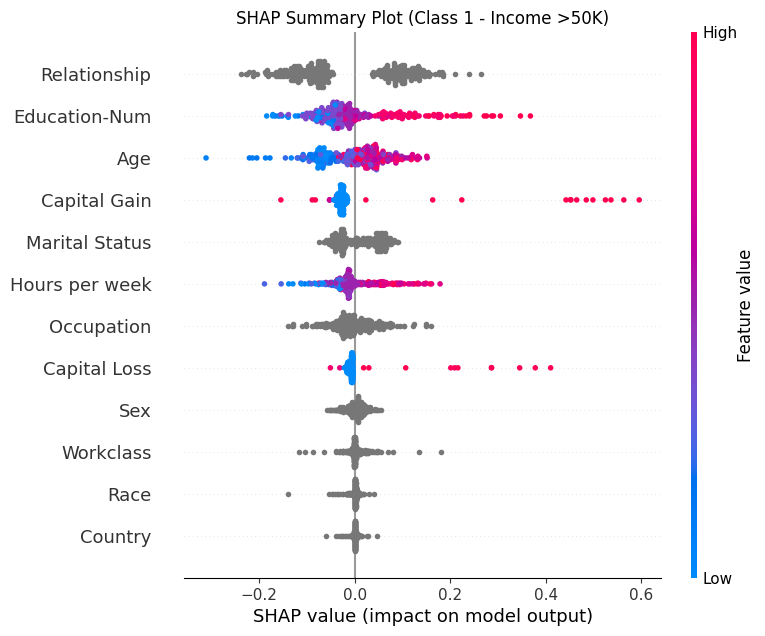

In [9]:
shap.summary_plot(shap_values[:, :, 1], X_test_display, show=False)  # Summary plot for class 1 (income >50K)
plt.title("SHAP Summary Plot (Class 1 - Income >50K)")
plt.show()

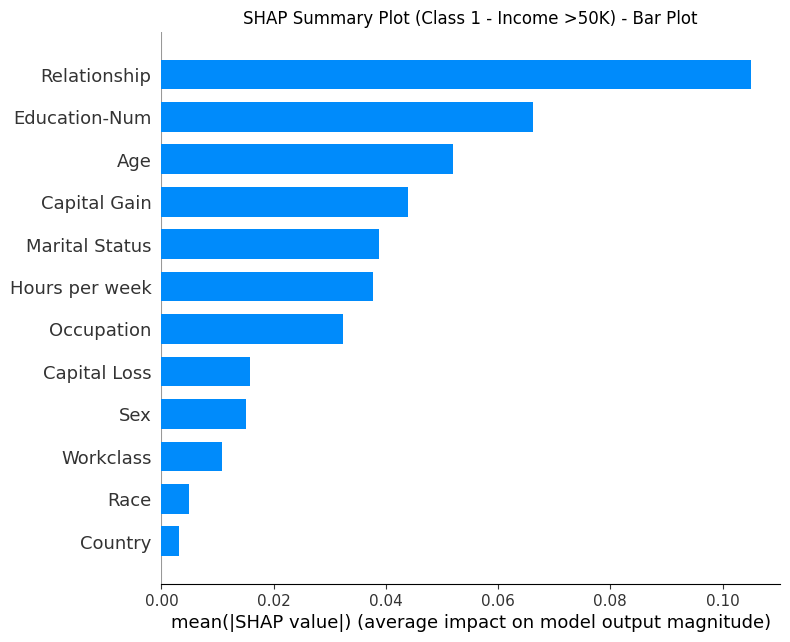

In [10]:
shap.summary_plot(shap_values[:, :, 1], X_test_display, show=False, plot_type='bar')  # Global importance for class 1 (income >50K)
plt.title("SHAP Summary Plot (Class 1 - Income >50K) - Bar Plot")
plt.show()

Based on feature order and SHAP-value ranges in the summary plots, the 5 most important features are:
1. Relationship
2. Education-Num
3. Age
4. Capital Gain
5. Marital Status

However, Hours per week and Occupation also appear relevant, as their average absolute SHAP values are still relatively high.

The color patterns in the beeswarm plot also show directionality: for Education-Num, Age, and Hours per week, higher feature values tend to push predictions toward the positive class (>50K).
For Capital Gain and Capital Loss, the pattern is similar between these two features: low values cluster close to zero SHAP contribution, while higher values are more widely spread.

### SHAP analysis - Dependence plots and individual explanations

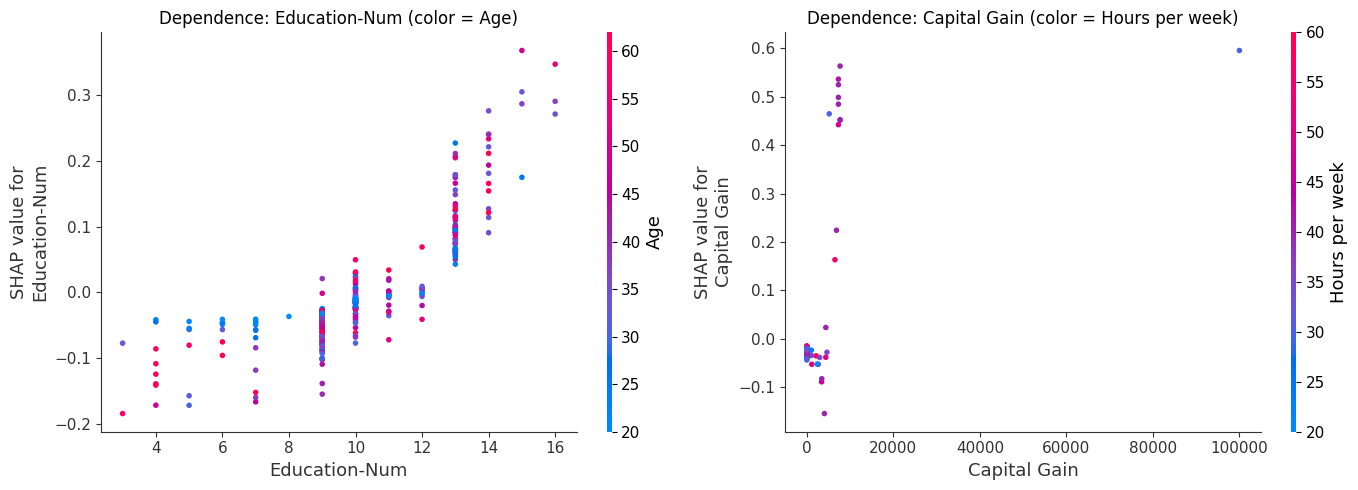

In [11]:
# Dependence plots: two relationships for class 1 (income >50K)
sv1 = shap_values[:, :, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

shap.dependence_plot(
    'Education-Num', sv1, X_test,
    interaction_index='Age',
    ax=axes[0], show=False
)
axes[0].set_title('Dependence: Education-Num (color = Age)')

shap.dependence_plot(
    'Capital Gain', sv1, X_test,
    interaction_index='Hours per week',
    ax=axes[1], show=False
)
axes[1].set_title('Dependence: Capital Gain (color = Hours per week)')

plt.tight_layout()
plt.show()

Dependence-plot interpretation:

1. Education-Num vs SHAP (color = Age): there is a clear upward trend. Lower education values are mostly associated with negative SHAP values, while higher education values (especially around 13-16) are associated with positive SHAP values. This means higher education generally pushes predictions toward >50K. The color pattern also points to an age-related difference: at lower education levels (around 3-6 years), younger people often show higher SHAP values than older people, while at higher education levels (around 15-16 years), this tendency appears to reverse. One possible interpretation is that with low formal education, younger people may more often be in physically demanding jobs where physical fitness can support higher earnings, whereas with high education, older people may benefit more from accumulated specialized knowledge and experience.
2. Capital Gain vs SHAP (color = Hours per week): most observations have capital gain close to 0 and SHAP values near zero or slightly negative. As capital gain increases, SHAP values become strongly positive and more spread out, indicating a stronger positive impact on the >50K prediction. The coloring by hours per week suggests there may be some relationship, but capital gain is still the main driver in this plot.

In [12]:
# Select one TP, TN, FP, FN example based on model predictions
pred = rf.predict(X_test)
proba = rf.predict_proba(X_test)[:, 1]

def pick_first(mask):
    idx = np.where(mask)[0]
    return int(idx[0]) if len(idx) > 0 else None

idx_tp = pick_first((y_test == 1) & (pred == 1))
idx_tn = pick_first((y_test == 0) & (pred == 0))
idx_fp = pick_first((y_test == 0) & (pred == 1))
idx_fn = pick_first((y_test == 1) & (pred == 0))

examples = {
    'TP': idx_tp,
    'TN': idx_tn,
    'FP': idx_fp,
    'FN': idx_fn,
}

print('Chosen example indices:', examples)
for label, idx in examples.items():
    if idx is not None:
        print(f"{label}: idx={idx}, y_true={int(y_test[idx])}, y_pred={int(pred[idx])}, p(>50K)={proba[idx]:.3f}")
    else:
        print(f"{label}: not available in this test split")

Chosen example indices: {'TP': 5, 'TN': 0, 'FP': 25, 'FN': 26}
TP: idx=5, y_true=1, y_pred=1, p(>50K)=0.578
TN: idx=0, y_true=0, y_pred=0, p(>50K)=0.060
FP: idx=25, y_true=0, y_pred=1, p(>50K)=0.560
FN: idx=26, y_true=1, y_pred=0, p(>50K)=0.264


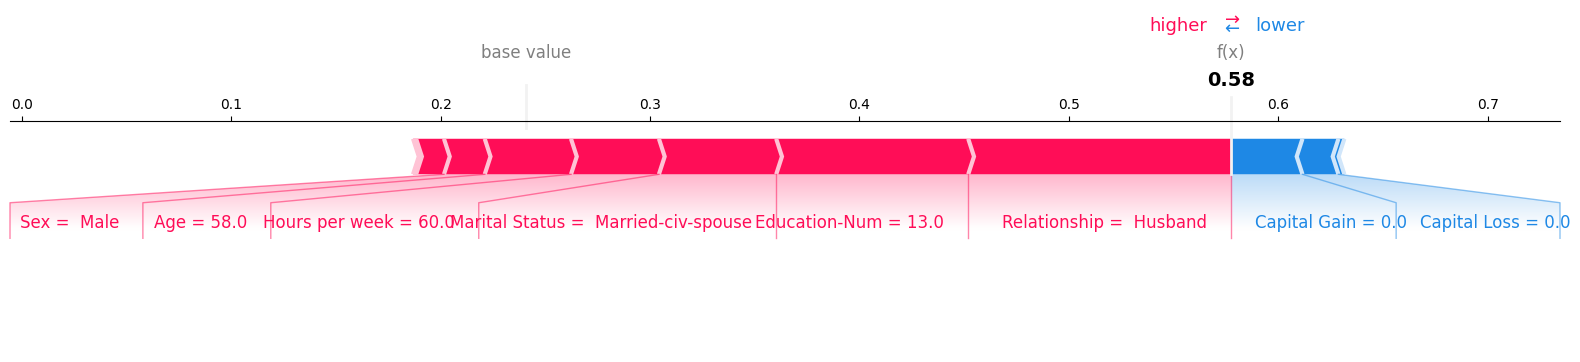

In [13]:
# TP force plot
if idx_tp is not None:
    shap.plots.force(explainer.expected_value[1], shap_values[idx_tp, :, 1], X_test_display.iloc[idx_tp, :], matplotlib=True)

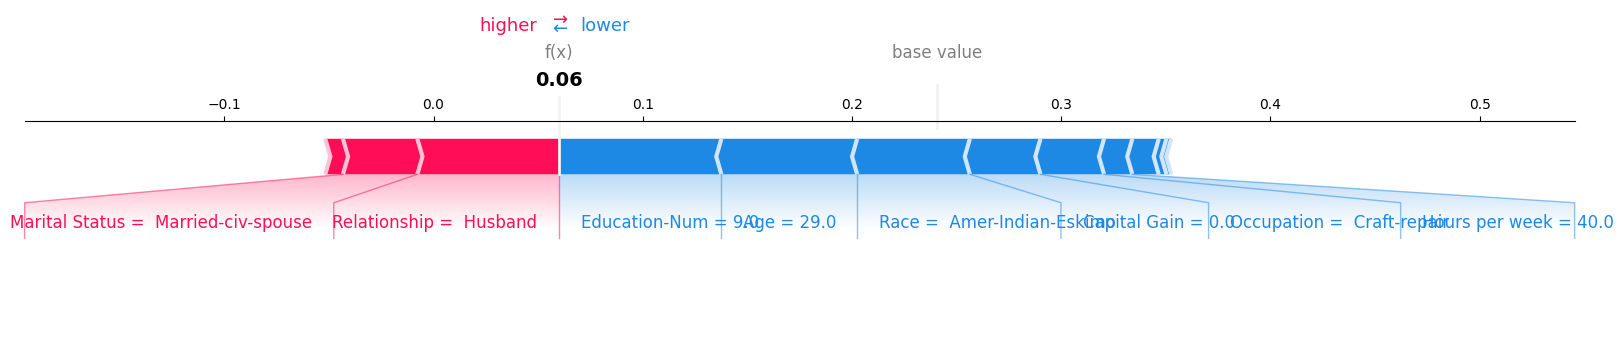

In [14]:
# TN force plot
if idx_tn is not None:
    shap.plots.force(explainer.expected_value[1], shap_values[idx_tn, :, 1], X_test_display.iloc[idx_tn, :], matplotlib=True)

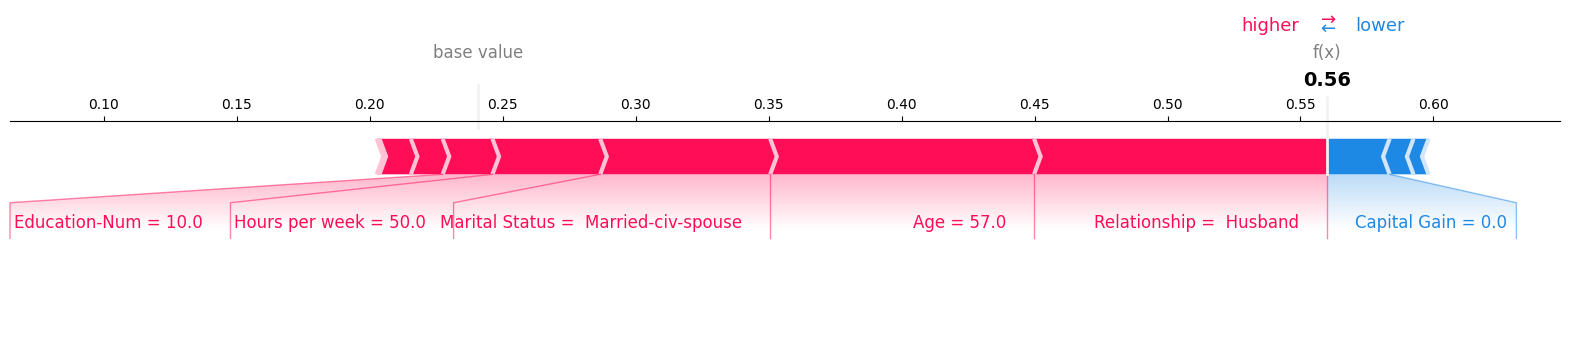

In [15]:
# FP force plot
if idx_fp is not None:
    shap.plots.force(explainer.expected_value[1], shap_values[idx_fp, :, 1], X_test_display.iloc[idx_fp, :], matplotlib=True)

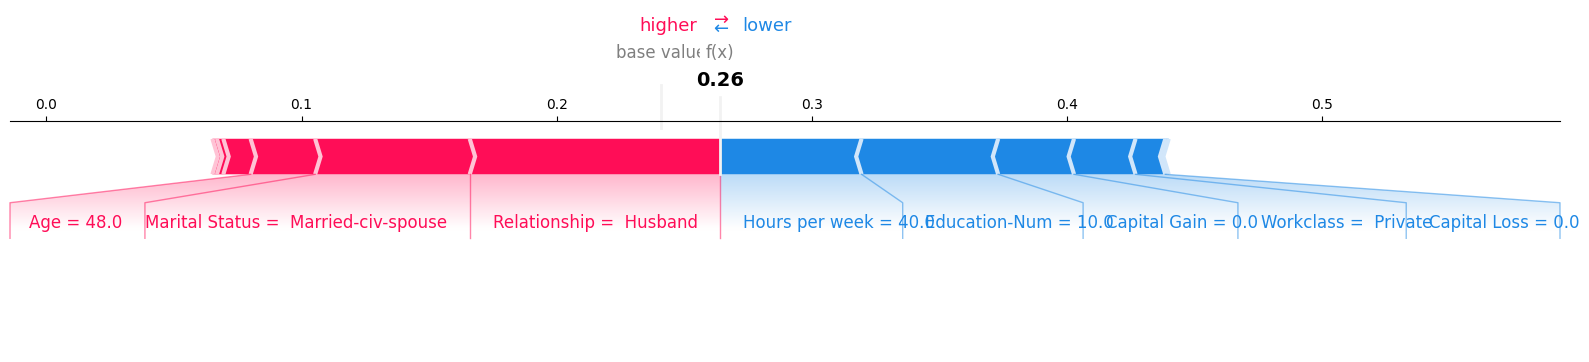

In [16]:
# FN force plot
if idx_fn is not None:
    shap.plots.force(explainer.expected_value[1], shap_values[idx_fn, :, 1], X_test_display.iloc[idx_fn, :], matplotlib=True)

In [17]:
# Top positive and negative SHAP contributors for each selected individual
feature_names = list(X_test.columns)


def top_contributors(idx, top_k=3):
    vals = shap_values[idx, :, 1]
    order = np.argsort(vals)
    neg_idx = order[:top_k]
    pos_idx = order[-top_k:][::-1]
    pos = [(feature_names[i], float(vals[i]), X_test_display.iloc[idx, i]) for i in pos_idx]
    neg = [(feature_names[i], float(vals[i]), X_test_display.iloc[idx, i]) for i in neg_idx]
    return pos, neg

for label, idx in [('TP', idx_tp), ('TN', idx_tn), ('FP', idx_fp), ('FN', idx_fn)]:
    if idx is None:
        print(f'\n{label}: not available')
        continue
    pos, neg = top_contributors(idx)
    print(f'\n{label} (idx={idx}, y_true={int(y_test[idx])}, y_pred={int(pred[idx])}, p(>50K)={proba[idx]:.3f})')
    print('  Top positive pushes toward >50K:')
    for f, s, v in pos:
        print(f'    + {f}: shap={s:.3f}, value={v}')
    print('  Top negative pushes toward <=50K:')
    for f, s, v in neg:
        print(f'    - {f}: shap={s:.3f}, value={v}')


TP (idx=5, y_true=1, y_pred=1, p(>50K)=0.578)
  Top positive pushes toward >50K:
    + Relationship: shap=0.126, value= Husband
    + Education-Num: shap=0.092, value=13.0
    + Marital Status: shap=0.056, value= Married-civ-spouse
  Top negative pushes toward <=50K:
    - Capital Gain: shap=-0.034, value=0.0
    - Capital Loss: shap=-0.017, value=0.0
    - Country: shap=-0.003, value= United-States

TN (idx=0, y_true=0, y_pred=0, p(>50K)=0.060)
  Top positive pushes toward >50K:
    + Relationship: shap=0.068, value= Husband
    + Marital Status: shap=0.036, value= Married-civ-spouse
    + Sex: shap=0.008, value= Male
  Top negative pushes toward <=50K:
    - Education-Num: shap=-0.078, value=9.0
    - Age: shap=-0.065, value=29.0
    - Race: shap=-0.054, value= Amer-Indian-Eskimo

FP (idx=25, y_true=0, y_pred=1, p(>50K)=0.560)
  Top positive pushes toward >50K:
    + Relationship: shap=0.110, value= Husband
    + Age: shap=0.099, value=57.0
    + Marital Status: shap=0.064, value= M

Force-plot interpretation for selected individuals (TP, TN, FP, FN):

1. **TP (idx=5, p(>50K)=0.578)**: Correct positive prediction. Strong positive pushes come from **Relationship = Husband** (+0.126), **Education-Num = 13** (+0.092), and **Marital Status = Married-civ-spouse** (+0.056). Negative pushes are weaker (mainly zero capital gain/loss), so the final output stays above threshold.
2. **TN (idx=0, p(>50K)=0.060)**: Correct negative prediction. Despite some positive social-status signals (Husband, Married-civ-spouse), stronger negatives dominate: **Education-Num = 9** (-0.078), **Age = 29** (-0.065), and **Race = Amer-Indian-Eskimo** (-0.054). This keeps prediction clearly in <=50K.
3. **FP (idx=25, p(>50K)=0.560)**: Incorrect positive prediction. The model is pulled upward by **Relationship = Husband** (+0.110), **Age = 57** (+0.099), and **Marital Status = Married-civ-spouse** (+0.064), while negative terms are relatively small (mostly zero capital gain/loss). This overestimates income and causes a false alarm.
4. **FN (idx=26, p(>50K)=0.264)**: Incorrect negative prediction. Positive social-status signals exist (**Husband**, **Married-civ-spouse**, age 48), but they are outweighed by negatives: **Hours per week = 40** (-0.055), **Education-Num = 10** (-0.054), and **Capital Gain = 0** (-0.030). The model underestimates this true >50K case.

These cases show how SHAP explains both correct decisions and errors: misclassifications happen when strong directional signals in a few features dominate the opposite evidence.

## Problem 2.2: LIME for Image Classification (25 points)
Use a pre-trained ResNet model on ImageNet:

• Select 5 images from different classes.

• Apply LIME to explain each prediction.

• Visualize superpixels that contribute most to predictions.

• Discuss whether explanations align with human intuition.

In [18]:
import torch
import torch.nn.functional as F
from PIL import Image  # loading and processing images
from torchvision import models, transforms  # for loading pre-trained ResNet and image transformations
from lime import lime_image  # for LIME image explanations
from skimage.segmentation import mark_boundaries
import glob  # for file handling and pattern matching
import os


### Load the pre-trained ResNet model (ResNet18)

In [19]:
weights = models.ResNet18_Weights.DEFAULT #you can also try ResNet50: larger but slower
model = models.resnet18(weights=weights)
model.eval()
categories = weights.meta["categories"]

### Load and preprocess images

Found 5 images in data/*.jpg


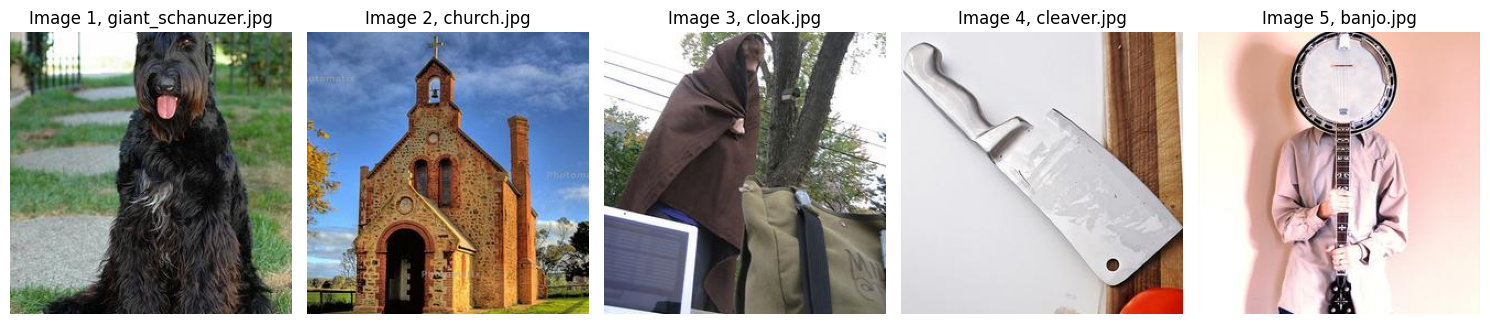

In [20]:
glob_path = "data/*.jpg"
image_paths = glob.glob(glob_path)
print(f"Found {len(image_paths)} images in {glob_path}")

images = []

# 5 images, plot them in a grid
fig = plt.figure(figsize=(15, 10))
for i, img_path in enumerate(image_paths[:5]):
    img = Image.open(img_path).convert('RGB')
    images.append(img)
    ax = fig.add_subplot(1, 5, i + 1)
    ax.imshow(img)
    ax.set_title(f"Image {i+1}, {os.path.basename(img_path)}")
    ax.axis('off')
plt.tight_layout()
plt.show()

In [21]:
# Preprocess all images 
preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

pre_processed_images = [preprocess(img).unsqueeze(0) for img in images]

### Predictions

In [22]:

for i, input_tensor in enumerate(pre_processed_images):
    with torch.no_grad():  # Disable gradient calculation for inference 
        output = model(input_tensor)  # Get raw output scores (logits) from the model
        probabilities = F.softmax(output[0], dim=0)  # Convert logits to probabilities
        top5_prob, top5_catid = torch.topk(probabilities, 5)  # Get top 5 probabilities and their corresponding category indices
    print(f"Image {i+1} ({os.path.basename(image_paths[i])}) - Top 5 predictions:")
    for j in range(top5_prob.size(0)):
        print(f"  {categories[top5_catid[j]]}: {top5_prob[j].item():.4f}")

Image 1 (giant_schanuzer.jpg) - Top 5 predictions:
  giant schnauzer: 0.8787
  standard schnauzer: 0.0779
  briard: 0.0261
  Bouvier des Flandres: 0.0146
  Kerry blue terrier: 0.0011
Image 2 (church.jpg) - Top 5 predictions:
  church: 0.6801
  monastery: 0.1735
  castle: 0.0704
  bell cote: 0.0449
  palace: 0.0190
Image 3 (cloak.jpg) - Top 5 predictions:
  cloak: 0.4267
  abaya: 0.1630
  suit: 0.0423
  trench coat: 0.0312
  solar dish: 0.0165
Image 4 (cleaver.jpg) - Top 5 predictions:
  cleaver: 0.7487
  scabbard: 0.1103
  letter opener: 0.0459
  corkscrew: 0.0402
  can opener: 0.0169
Image 5 (banjo.jpg) - Top 5 predictions:
  corkscrew: 0.4563
  banjo: 0.2860
  oboe: 0.1203
  chain: 0.0298
  unicycle: 0.0177


4 predictions are correct, for banjo model chose corkscrew over banjo. The reason for that could be that banjo is held upside down which makes it look more like a corkscrew. 

### LIME explanations and visualizations

100%|██████████| 1000/1000 [00:14<00:00, 69.72it/s]



Image 1: Top 5 positive superpixels for class 'giant schnauzer' (same criterion as plot)
Feature ID | Importance Weight
----------------------------
    19     | 0.2948
    8      | 0.2670
    26     | 0.0882
    9      | 0.0765
    35     | 0.0660


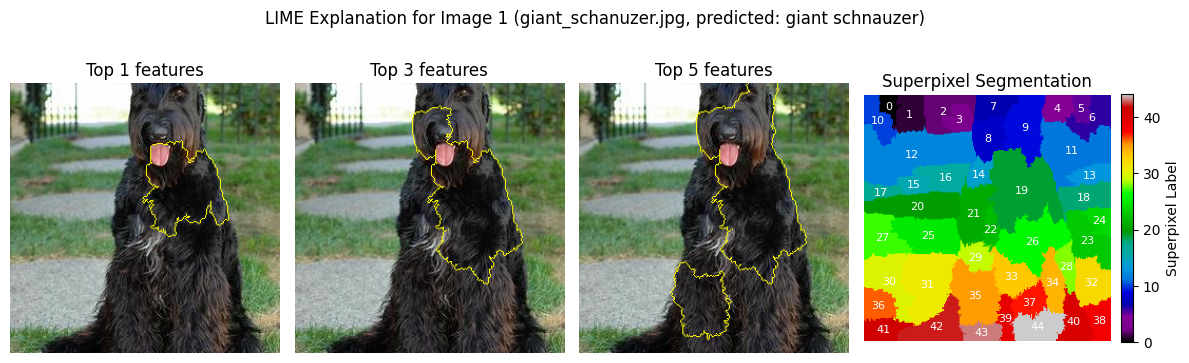

100%|██████████| 1000/1000 [00:14<00:00, 68.98it/s]



Image 2: Top 5 positive superpixels for class 'church' (same criterion as plot)
Feature ID | Importance Weight
----------------------------
    2      | 0.1078
    23     | 0.0882
    14     | 0.0727
    29     | 0.0590
    17     | 0.0577


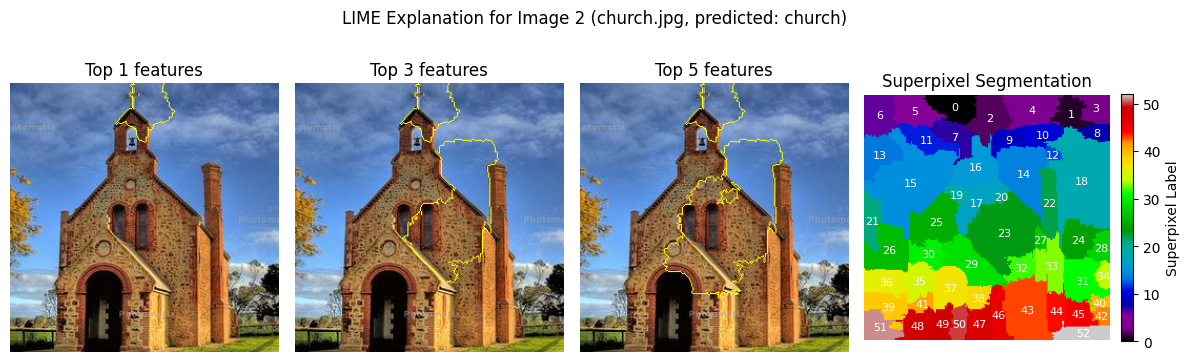

100%|██████████| 1000/1000 [00:15<00:00, 64.55it/s]



Image 3: Top 5 positive superpixels for class 'cloak' (same criterion as plot)
Feature ID | Importance Weight
----------------------------
    3      | 0.0121
    18     | 0.0092
    5      | 0.0086
    23     | 0.0078
    1      | 0.0059


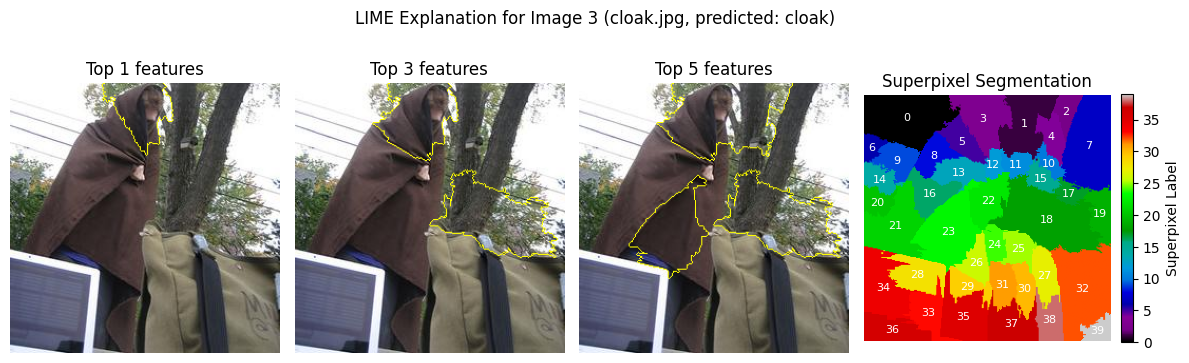

100%|██████████| 1000/1000 [00:14<00:00, 69.00it/s]



Image 4: Top 5 positive superpixels for class 'cleaver' (same criterion as plot)
Feature ID | Importance Weight
----------------------------
    25     | 0.0121
    16     | 0.0108
    21     | 0.0105
    12     | 0.0104
    23     | 0.0096


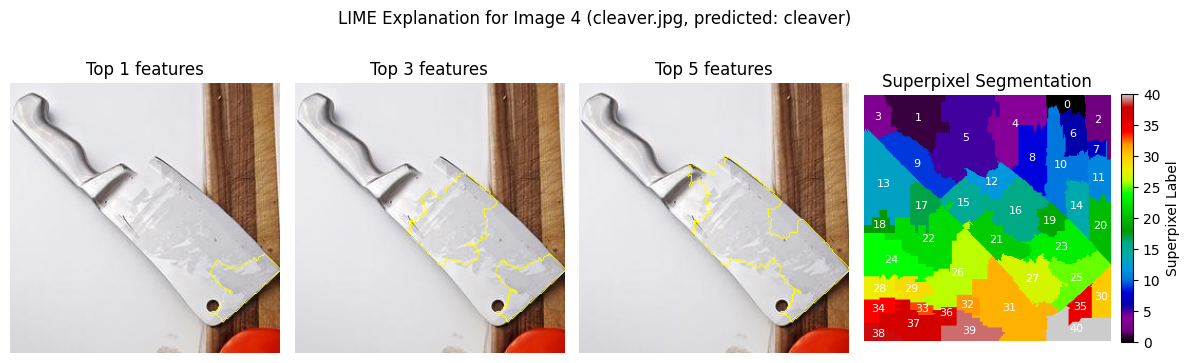

100%|██████████| 1000/1000 [00:14<00:00, 68.84it/s]



Image 5: Top 5 positive superpixels for class 'corkscrew' (same criterion as plot)
Feature ID | Importance Weight
----------------------------
    10     | 0.0133
    3      | 0.0121
    12     | 0.0111
    13     | 0.0110
    31     | 0.0088


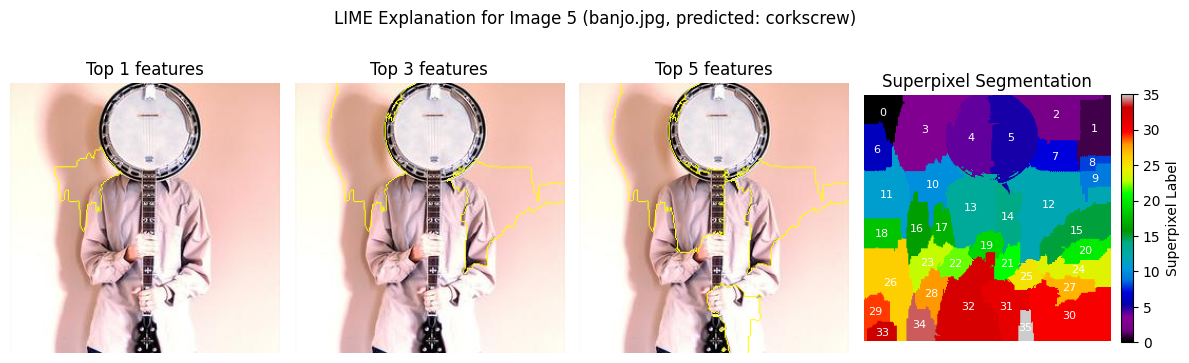

In [23]:
explainer = lime_image.LimeImageExplainer(random_state=SEED)

def predict_fn(images):  # LIME expects a function that takes a list of images and returns a 2D array of class probabilities
    model.eval()  # Ensure the model is in evaluation mode
    batch = torch.stack([preprocess(Image.fromarray(img)).unsqueeze(0) for img in images], dim=0).squeeze(1)  # Preprocess and batch the images
    with torch.no_grad():
        outputs = model(batch)
        probabilities = F.softmax(outputs, dim=1).cpu().numpy()  # Convert to numpy array for LIME
    return probabilities

for i, img in enumerate(images):
    explanation = explainer.explain_instance(np.array(img), predict_fn, top_labels=5, hide_color=0, num_samples=1000)  # Generate LIME explanation for the image

    top_class = explanation.top_labels[0]
    dict_heatmap = explanation.local_exp[top_class]

    # Match printed features to plotted ones: plot uses positive_only=True and num_features in [1, 3, 5].
    n_print = 5
    positive_features = [(fid, w) for fid, w in dict_heatmap if w > 0]
    positive_features = sorted(positive_features, key=lambda x: x[1], reverse=True)[:n_print]

    print(f"\nImage {i+1}: Top {n_print} positive superpixels for class '{categories[top_class]}' (same criterion as plot)")
    print("Feature ID | Importance Weight")
    print("----------------------------")
    for feature_id, weight in positive_features:
        print(f"{feature_id:^10} | {weight:.4f}")

    fig = plt.figure(figsize=(12, 4))
    for nf in [1, 3, 5]:  # Show explanations for top 1, 3, and 5 features
        temp, mask = explanation.get_image_and_mask(explanation.top_labels[0], positive_only=True, num_features=nf, hide_rest=False)
        ax = fig.add_subplot(1, 4, nf // 2 + 1)
        ax.imshow(mark_boundaries(temp / 255.0, mask))
        ax.set_title(f"Top {nf} features")
        ax.axis('off')
    segments = explanation.segments
    ax = fig.add_subplot(1, 4, 4)
    im = ax.imshow(segments, cmap='nipy_spectral')
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Superpixel Label')
    for label in np.unique(segments):
        y, x = np.where(segments == label)
        ax.text(x.mean(), y.mean(), str(label), color='white', fontsize=8, ha='center', va='center')
    ax.set_title("Superpixel Segmentation")
    ax.axis('off')
        
    plt.suptitle(f"LIME Explanation for Image {i+1} ({os.path.basename(image_paths[i])}, predicted: {categories[explanation.top_labels[0]]})")
    plt.tight_layout()
    plt.show()

**Image 1 (giant schanuzer)** &ndash; The superpixels that push the prediction forward the most include the dog's tongue and nose. Other important regions also cover parts of the hair. As we add the next most influential superpixels, a larger part of the dog's face and body becomes visible. This suggests that the model focuses on key visual features of the dog, which is consistent with how we would expect a model to identify this class. This also aligns with the high confidence for the "giant schnauzer" prediction.

**Image 2 (church)** &ndash; Most important superpixel includes the top of the church, which is a key feature for identifying it as it includes the cross. Analyzing the rest of the 5 most important features we can observe that the model is focusing on the upper part of the building, as well as part of the sky. As these parts of the image can look similar for monastery, it explains why the probability for the this class is also relatively high (0.17). Nevertheless, the model correctly identifies the image as a church with the highest probability (0.68), using key visual features that are characteristic of churches.

**Image 3 (cloak)** &ndash; The most important superpixel mainly highlights the hood region, which also includes part of the person's face. The second and third most important superpixels include the upper part of the cloak and part of the surroundings. When looking at the top 5 features, the highlighted regions also include parts of the cloak material and a tree in the background. This suggests the model may rely on contextual cues, which can cause mistakes. The prediction is correct, but the confidence is moderate (0.43). A likely reason is class similarity in ImageNet (for example, "abaya" or "suit"), where overlapping visual cues can increase uncertainty.

**Image 4 (cleaver):** The top highlighted regions are on the blade, which is the most distinctive part of a cleaver. The model focuses on the blade’s broad shape and visible texture. The prediction is correct, with the the probability for the cleaver class being relatively high (0.75).

**Image 5 (banjo):**  &ndash; This is the only image where the model’s top prediction is incorrect. The most influential superpixels do not focus on the banjo itself. Instead, they highlight the banjo’s shadow on the wall and the arms of the person holding it. A likely reason is that the instrument is held in an unusual position, so its shape appears less typical. Some highlighted regions can resemble features of a corkscrew, which explains why "corkscrew" is predicted as the most likely class (0.46).

## Problem 2.3: Counterfactual Explanations (25 points)
Generate counterfactual explanations for a credit approval model:

• Train a neural network classifier on the German Credit dataset.

• For 5 rejected applications, generate counterfactuals that would lead to
approval.

• Ensure counterfactuals are realistic (minimal changes, feasible values).

• Compare with SHAP explanations for the same instances.

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import dice_ml

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.datasets import fetch_openml

import warnings
warnings.filterwarnings('ignore')

### Load the data

In [25]:
german_credit = fetch_openml(data_id=31, as_frame=True, parser="pandas")

# Extract features and target
X = german_credit.data
y = german_credit.target
print(german_credit.DESCR)

**Author**: Dr. Hans Hofmann  
**Source**: [UCI](https://archive.ics.uci.edu/ml/datasets/statlog+(german+credit+data)) - 1994    
**Please cite**: [UCI](https://archive.ics.uci.edu/ml/citation_policy.html)

**German Credit dataset**  
This dataset classifies people described by a set of attributes as good or bad credit risks.

This dataset comes with a cost matrix: 
``` 
Good  Bad (predicted)  
Good   0    1   (actual)  
Bad    5    0  
```

It is worse to class a customer as good when they are bad (5), than it is to class a customer as bad when they are good (1).  

### Attribute description  

1. Status of existing checking account, in Deutsche Mark.  
2. Duration in months  
3. Credit history (credits taken, paid back duly, delays, critical accounts)  
4. Purpose of the credit (car, television,...)  
5. Credit amount  
6. Status of savings account/bonds, in Deutsche Mark.  
7. Present employment, in number of years.  
8. Installment rate in percentage of disposable income  
9. Perso

In [26]:
print("Categorical feature categories:", end='\n\n')
for c in X.columns:
    if X[c].dtype == 'object' or X[c].dtype.name == 'category':
        print(f"{c}: {X[c].cat.categories.tolist()}")

Categorical feature categories:

checking_status: ['0<=X<200', '<0', '>=200', 'no checking']
credit_history: ['all paid', 'critical/other existing credit', 'delayed previously', 'existing paid', 'no credits/all paid']
purpose: ['domestic appliance', 'new car', 'used car', 'business', 'education', 'furniture/equipment', 'other', 'radio/tv', 'repairs', 'retraining']
savings_status: ['100<=X<500', '500<=X<1000', '<100', '>=1000', 'no known savings']
employment: ['1<=X<4', '4<=X<7', '<1', '>=7', 'unemployed']
personal_status: ['female div/dep/mar', 'male div/sep', 'male mar/wid', 'male single']
other_parties: ['co applicant', 'guarantor', 'none']
property_magnitude: ['life insurance', 'no known property', 'real estate', 'car']
other_payment_plans: ['bank', 'none', 'stores']
housing: ['for free', 'own', 'rent']
job: ['high qualif/self emp/mgmt', 'unemp/unskilled non res', 'unskilled resident', 'skilled']
own_telephone: ['none', 'yes']
foreign_worker: ['no', 'yes']


In [27]:
print(f"\nNumerical feature statistics:")
X.describe()


Numerical feature statistics:


,duration,credit_amount,installment_commitment,residence_since,age,existing_credits,num_dependents
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000


In [28]:
y_raw = y.copy()
y_str = y_raw.astype(str).str.strip().str.lower()

approval_label = "good"
rejected_label = "bad"

y_bin = (y_str == approval_label).astype(int)

print("Class counts:")
print(y_str.value_counts())

Class counts:
class
good    700
bad     300
Name: count, dtype: int64


### MLP classifier training


MLP evaluation on test set:
              precision    recall  f1-score   support

    Rejected     0.5250    0.3500    0.4200        60
    Approved     0.7562    0.8643    0.8067       140

    accuracy                         0.7100       200
   macro avg     0.6406    0.6071    0.6133       200
weighted avg     0.6869    0.7100    0.6907       200



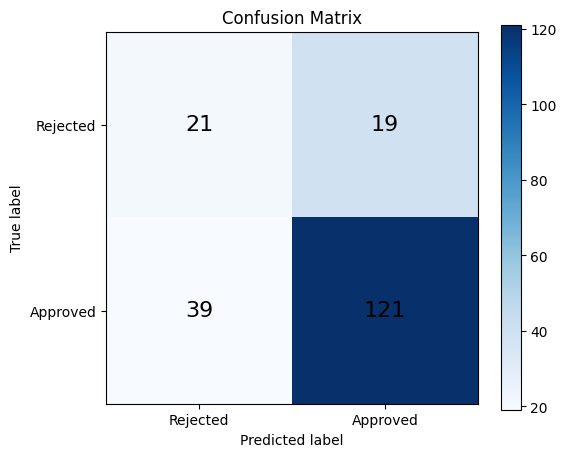

In [41]:
# --- Feature types ---
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()

ordered_categorical_features = ["checking_status", "savings_status", "employment", "job"]
checking_status_order = ["<0", "no checking", "0<=X<200", ">=200"]
savings_order = ["no known savings", "<100", "100<=X<500", "500<=X<1000", ">=1000"]
employment_order = ["unemployed", "<1", "1<=X<4", "4<=X<7", ">=7"]
job_order = ["unemp/unskilled non res", "unskilled resident", "skilled", "high qualif/self emp/mgmt"]
categorical_features = [c for c in X.columns if (c not in numeric_features) and (c not in ordered_categorical_features)]



# OneHotEncoder arg changed across sklearn versions
try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("ord_checking_status", OrdinalEncoder(categories=[checking_status_order]), ["checking_status"]),
        ("ord_savings_status", OrdinalEncoder(categories=[savings_order]), ["savings_status"]),
        ("ord_employment", OrdinalEncoder(categories=[employment_order]), ["employment"]),
        ("ord_job", OrdinalEncoder(categories=[job_order]), ["job"]),
        ("cat", ohe, categorical_features),
    ]
)

mlp_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "clf",
            MLPClassifier(
                hidden_layer_sizes=(64, 32),
                activation="relu",
                solver="adam",
                alpha=1e-4,
                learning_rate_init=1e-3,
                max_iter=800,
                early_stopping=True,
                n_iter_no_change=20,
                random_state=SEED,
            ),
        ),
    ]
)

# --- Train / test split and model fit ---
X_train, X_test, y_train, y_test = train_test_split(
    X.copy(), y_bin, test_size=0.2, random_state=SEED, stratify=y_bin
)

mlp_pipeline.fit(X_train, y_train)

# --- Prediction on test set ---
y_pred = mlp_pipeline.predict(X_test)
y_proba = mlp_pipeline.predict_proba(X_test)[:, 1]

print("\nMLP evaluation on test set:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Rejected", "Approved"],
        digits=4,
    )
)

# plot confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.colorbar()
tick_marks = np.arange(2)
plt.xticks(tick_marks, ["Rejected", "Approved"])
plt.yticks(tick_marks, ["Rejected", "Approved"])
plt.text(0, 0, str(cm[0, 0]), ha="center", va="center", color="black", fontsize=16)
plt.text(0, 1, str(cm[0, 1]), ha="center", va="center", color="black", fontsize=16)
plt.text(1, 0, str(cm[1, 0]), ha="center", va="center", color="black", fontsize=16)
plt.text(1, 1, str(cm[1, 1]), ha="center", va="center", color="black", fontsize=16)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.show()

# Keep a convenient table for later cells
test_results = X_test.copy()
test_results["y_true"] = y_test.values
test_results["y_pred"] = y_pred
test_results["p_approval"] = y_proba

### Counterfactuals for 5 rejected applications (DiCE, actionable features only)

In [ ]:
import random

actionable_features = [
    "checking_status",
    "duration",
    "credit_amount",
    "savings_status",
    "employment",
    "installment_commitment",
    "job",
    "own_telephone"
]
print("Actionable features used:", actionable_features)

# Keep DiCE search deterministic for reproducible counterfactuals
random.seed(SEED)
np.random.seed(SEED)

# Select 5 easier rejected applications from the test set
# We keep only cases that are truly rejected and predicted rejected, then
# sort them by approval probability so we explain the ones closest to approval.
mask_true_and_pred_rejected = (y_test == 0) & (y_pred == 0)
rejected_candidates = X_test.loc[mask_true_and_pred_rejected].copy()
rejected_candidates["p_approval"] = y_proba[mask_true_and_pred_rejected]
rejected_candidates = rejected_candidates.sort_values(
    ["p_approval"], ascending=[False], kind="mergesort"
 )
rejected_idx = rejected_candidates.index[:5]
rejected_apps = rejected_candidates.loc[rejected_idx].drop(columns=["p_approval"]).copy()

print(f"\nSelected {len(rejected_apps)} rejected applications for counterfactuals.")
if len(rejected_apps) < 5:
    print("Warning: fewer than 5 rejected applications found in this split.")

# Build DiCE data/model objects
dice_train_df = X_train.copy()
dice_train_df["target"] = y_train.values

dice_data = dice_ml.Data(
    dataframe=dice_train_df,
    continuous_features=numeric_features,
    outcome_name="target",
)
dice_model = dice_ml.Model(model=mlp_pipeline, backend="sklearn", model_type="classifier")
dice_exp = dice_ml.Dice(dice_data, dice_model, method="genetic")  # "genetic" method for more realistic counterfactuals, but can be slower than "random"

# Helper: neighborhood values for ordered categorical levels
def neighbor_levels(value, ordered_levels):
    value = str(value)
    levels = [str(v) for v in ordered_levels]
    if value not in levels:
        return levels
    i = levels.index(value)
    keep = {levels[i]}
    if i - 1 >= 0:
        keep.add(levels[i - 1])
    if i + 1 < len(levels):
        keep.add(levels[i + 1])
    return [v for v in levels if v in keep]


counterfactual_results = {}

for offset, (ridx, row) in enumerate(rejected_apps.iterrows()):
    # Re-seed per instance to make each generated CF set stable across reruns.
    run_seed = SEED + offset
    random.seed(run_seed)
    np.random.seed(run_seed)

    query_df = row.to_frame().T

    # Per-person feasibility constraints
    permitted_range = {}

    if "checking_status" in actionable_features and "checking_status" in row.index:
        current_c = str(row["checking_status"])
        # Keep to current/adjacent status to enforce "small changes"
        permitted_range["checking_status"] = neighbor_levels(current_c, checking_status_order)

    if "duration" in actionable_features and "duration" in row.index:
        d0 = float(row["duration"])
        dmin, dmax = X["duration"].min(), X["duration"].max()
        permitted_range["duration"] = [max(dmin, d0 * 0.80), min(dmax, d0 * 1.20)]

    if "credit_amount" in actionable_features and "credit_amount" in row.index:
        c0 = float(row["credit_amount"])
        cmin, cmax = X["credit_amount"].min(), X["credit_amount"].max()
        permitted_range["credit_amount"] = [max(cmin, c0 * 0.90), min(cmax, c0 * 1.10)]

    if "installment_commitment" in actionable_features and "installment_commitment" in row.index:
        i0 = float(row["installment_commitment"])
        imin, imax = X["installment_commitment"].min(), X["installment_commitment"].max()
        permitted_range["installment_commitment"] = [max(imin, i0 - 1), min(imax, i0 + 1)]

    if "savings_status" in actionable_features and "savings_status" in row.index:
        current_s = str(row["savings_status"])
        # Keep to current/adjacent status to enforce "small changes"
        permitted_range["savings_status"] = neighbor_levels(current_s, savings_order)

    if "employment" in actionable_features and "employment" in row.index:
        current_e = str(row["employment"])
        # Explicitly allow unemployed -> <1 transition
        if current_e == "unemployed":
            permitted_range["employment"] = ["<1"]
        else: # One can only move to <1 from any other status
            permitted_range["employment"] = ["<1"]
            # permitted_range["employment"] = neighbor_levels(current_e, employment_order)
    
    if "job" in actionable_features and "job" in row.index:
        current_j = str(row["job"])
        # Keep to current/adjacent status to enforce "small changes"
        permitted_range["job"] = neighbor_levels(current_j, job_order)

    if "own_telephone" in actionable_features and "own_telephone" in row.index:
        # Allow getting a phone if one doesn't have it, but not losing it if one has it
        if row["own_telephone"] == 0:
            permitted_range["own_telephone"] = ["yes", "no"]
        else:
            permitted_range["own_telephone"] = ["yes"]

    cf = dice_exp.generate_counterfactuals(
        query_instances=query_df,
        total_CFs=4,
        desired_class=1,
        features_to_vary=actionable_features,
        permitted_range=permitted_range,
        verbose=False,
    )

    cf_df = cf.cf_examples_list[0].final_cfs_df
    counterfactual_results[ridx] = {
        "query": query_df,
        "cfs": cf_df,
        "permitted_range": permitted_range,
    }

    print(f"\nRejected application index: {ridx}")
    print(f"Original features:\n{query_df.to_string(index=False)}")
    print(f"Features allowed to vary: \n{query_df[actionable_features].to_string(index=False)}")
    print(f"Original approval probability: {mlp_pipeline.predict_proba(query_df)[0, 1]:.4f}")
    print("Counterfactuals (approval-targeted):")
    display_cols = actionable_features + ["target"]
    display_cols = [c for c in display_cols if c in cf_df.columns]
    print(cf_df[display_cols].to_string(index=False))

Actionable features used: ['checking_status', 'duration', 'credit_amount', 'savings_status', 'employment', 'installment_commitment', 'job', 'own_telephone']

Selected 5 rejected applications for counterfactuals.


100%|██████████| 1/1 [00:00<00:00,  4.11it/s]



Rejected application index: 634
Original features:
checking_status duration credit_history purpose credit_amount savings_status employment installment_commitment    personal_status other_parties residence_since property_magnitude age other_payment_plans housing existing_credits                job num_dependents own_telephone foreign_worker
       0<=X<200       24  existing paid new car          1355           <100         <1                      3 female div/dep/mar          none               4                car  25                none     own                1 unskilled resident              1           yes            yes
Features allowed to vary: 
checking_status duration credit_amount savings_status employment installment_commitment                job own_telephone
       0<=X<200       24          1355           <100         <1                      3 unskilled resident           yes
Original approval probability: 0.4920
Counterfactuals (approval-targeted):
checking_status durati

100%|██████████| 1/1 [00:00<00:00,  4.21it/s]



Rejected application index: 633
Original features:
checking_status duration credit_history             purpose credit_amount savings_status employment installment_commitment    personal_status other_parties residence_since property_magnitude age other_payment_plans housing existing_credits     job num_dependents own_telephone foreign_worker
    no checking        9  existing paid furniture/equipment          1980           <100         <1                      2 female div/dep/mar  co applicant               2                car  19                none    rent                2 skilled              1          none            yes
Features allowed to vary: 
checking_status duration credit_amount savings_status employment installment_commitment     job own_telephone
    no checking        9          1980           <100         <1                      2 skilled          none
Original approval probability: 0.4912
Counterfactuals (approval-targeted):
checking_status duration credit_amount sav

100%|██████████| 1/1 [00:00<00:00,  3.63it/s]



Rejected application index: 194
Original features:
checking_status duration credit_history  purpose credit_amount savings_status employment installment_commitment personal_status other_parties residence_since property_magnitude age other_payment_plans housing existing_credits     job num_dependents own_telephone foreign_worker
       0<=X<200       45  existing paid radio/tv          3031     100<=X<500     1<=X<4                      4     male single     guarantor               4     life insurance  21                none    rent                1 skilled              1          none            yes
Features allowed to vary: 
checking_status duration credit_amount savings_status employment installment_commitment     job own_telephone
       0<=X<200       45          3031     100<=X<500     1<=X<4                      4 skilled          none
Original approval probability: 0.4867
Counterfactuals (approval-targeted):
checking_status duration credit_amount savings_status employment insta

100%|██████████| 1/1 [00:00<00:00,  3.43it/s]



Rejected application index: 4
Original features:
checking_status duration     credit_history purpose credit_amount savings_status employment installment_commitment personal_status other_parties residence_since property_magnitude age other_payment_plans  housing existing_credits     job num_dependents own_telephone foreign_worker
             <0       24 delayed previously new car          4870           <100     1<=X<4                      3     male single          none               4  no known property  53                none for free                2 skilled              2          none            yes
Features allowed to vary: 
checking_status duration credit_amount savings_status employment installment_commitment     job own_telephone
             <0       24          4870           <100     1<=X<4                      3 skilled          none
Original approval probability: 0.4709
Counterfactuals (approval-targeted):
checking_status duration credit_amount savings_status employment

100%|██████████| 1/1 [00:00<00:00,  4.26it/s]


Rejected application index: 257
Original features:
checking_status duration credit_history  purpose credit_amount savings_status employment installment_commitment personal_status other_parties residence_since property_magnitude age other_payment_plans  housing existing_credits     job num_dependents own_telephone foreign_worker
             <0       12       all paid radio/tv          2149           <100     1<=X<4                      4    male div/sep          none               1  no known property  29                none for free                1 skilled              1          none            yes
Features allowed to vary: 
checking_status duration credit_amount savings_status employment installment_commitment     job own_telephone
             <0       12          2149           <100     1<=X<4                      4 skilled          none
Original approval probability: 0.4495
Counterfactuals (approval-targeted):
checking_status duration credit_amount savings_status employment ins

### SHAP force plots for the same 5 rejected applications

Using 120 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.
100%|██████████| 5/5 [00:00<00:00, 84.47it/s]


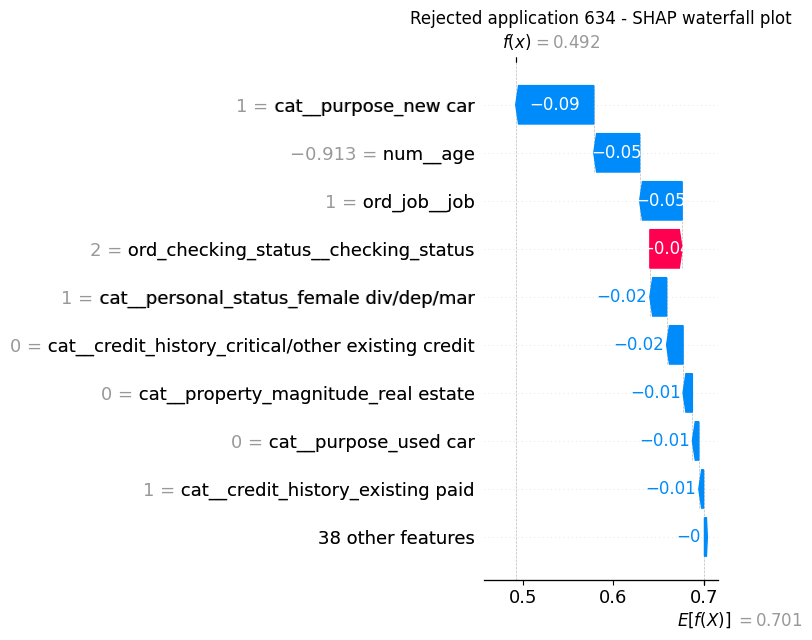

In [68]:
# SHAP on transformed feature space (MLP input after preprocessing)
pre_fitted = mlp_pipeline.named_steps["preprocessor"]
mlp_fitted = mlp_pipeline.named_steps["clf"]

feature_names_transformed = pre_fitted.get_feature_names_out()

X_train_trans = pre_fitted.transform(X_train)
X_rej_trans = pre_fitted.transform(rejected_apps)

# Small background sample for KernelExplainer speed
bg_n = min(120, len(X_train))
bg_idx = np.random.RandomState(SEED).choice(len(X_train), size=bg_n, replace=False)
X_bg = X_train_trans[bg_idx]

predict_approval_from_transformed = lambda z: mlp_fitted.predict_proba(z)[:, 1]

kernel_explainer = shap.KernelExplainer(predict_approval_from_transformed, X_bg)
shap_values_rej = kernel_explainer.shap_values(X_rej_trans, nsamples=300)

# Handle SHAP return format across versions
if isinstance(shap_values_rej, list):
    shap_values_rej = shap_values_rej[0]

expected_value = kernel_explainer.expected_value
if isinstance(expected_value, (list, np.ndarray)):
    expected_value = np.array(expected_value).reshape(-1)[0]

ridx = rejected_apps.index[0]
explanation_i = shap.Explanation(
    values=shap_values_rej[0],
    base_values=expected_value,
    data=X_rej_trans[0],
    feature_names=feature_names_transformed,
)

plt.figure(figsize=(10, 6))
shap.plots.waterfall(explanation_i, max_display=10, show=False)
plt.title(f"Rejected application {ridx} - SHAP waterfall plot")
plt.tight_layout()
plt.show()

The prediction is pushed toward approval mainly by checking status.
From the counterfactual results, two main paths appear: increase savings while remaining unskilled, or keep saving at the same level and move to skilled job status.
Counterfactuals also include small changes in credit amount, which suggests that it can contribute to flipping the decision.

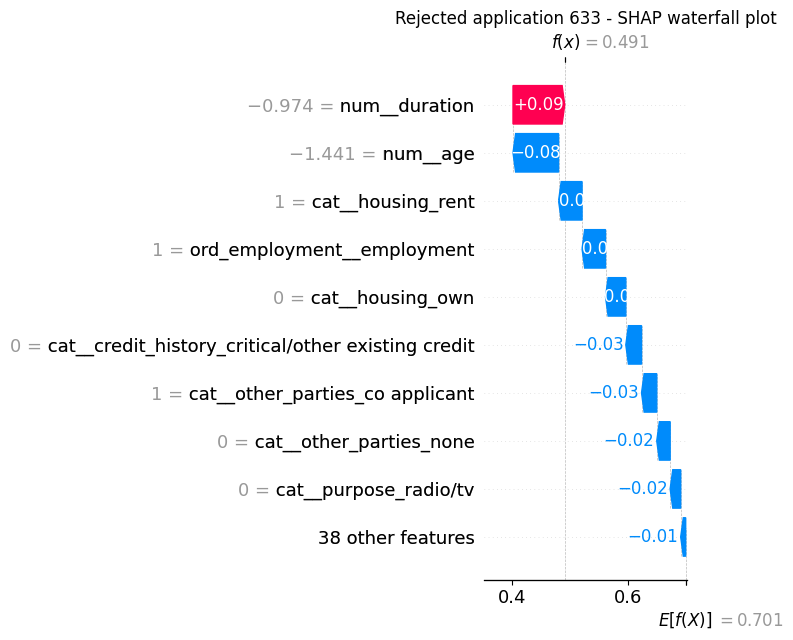

In [72]:
ridx = rejected_apps.index[1]
explanation_i = shap.Explanation(
    values=shap_values_rej[1],
    base_values=expected_value,
    data=X_rej_trans[1],
    feature_names=feature_names_transformed,
)

plt.figure(figsize=(10, 6))
shap.plots.waterfall(explanation_i, max_display=10, show=False)
plt.title(f"Rejected application {ridx} - SHAP waterfall plot")
plt.tight_layout()
plt.show()

Positive pressure comes mainly from duration.
Most of the strongest negative drivers are not easy to change directly.
From the counterfactual results, the practical changes suggested for this case are a small adjustment in credit amount and obtaining a telephone.

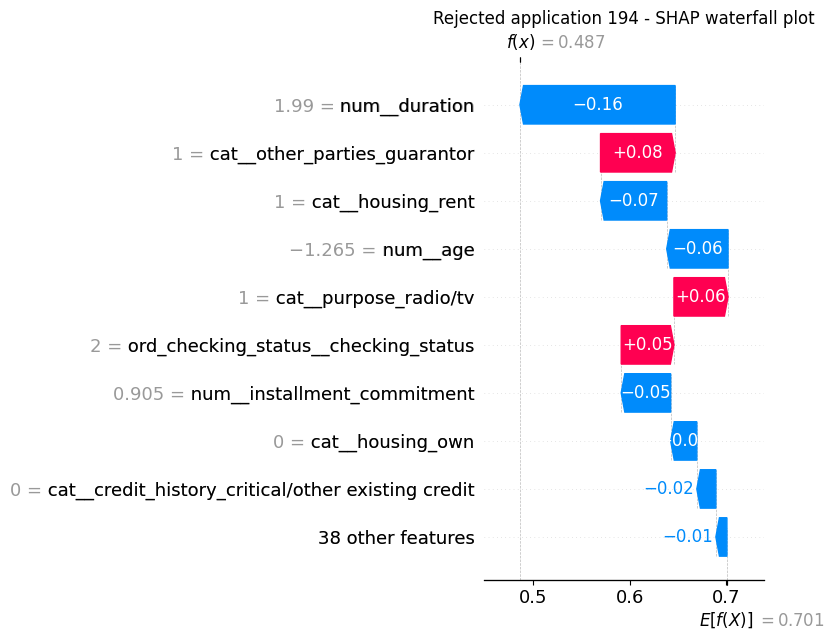

In [73]:
ridx = rejected_apps.index[2]
explanation_i = shap.Explanation(
    values=shap_values_rej[2],
    base_values=expected_value,
    data=X_rej_trans[2],
    feature_names=feature_names_transformed,
)

plt.figure(figsize=(10, 6))
shap.plots.waterfall(explanation_i, max_display=10, show=False)
plt.title(f"Rejected application {ridx} - SHAP waterfall plot")
plt.tight_layout()
plt.show()

The main negative driver in this case is duration.
What is interesting is that the counterfactual analysis does not propose changing it.
Instead, it again suggests adjusting credit amount and obtaining a telephone.
It also proposes changing employment status from 1-4 years of work to <1 (a new job). One possible interpretation is that changing jobs can be associated with obtaining a higher salary and additional benefits, which supports overall financial growth and may improve the approval outcome.

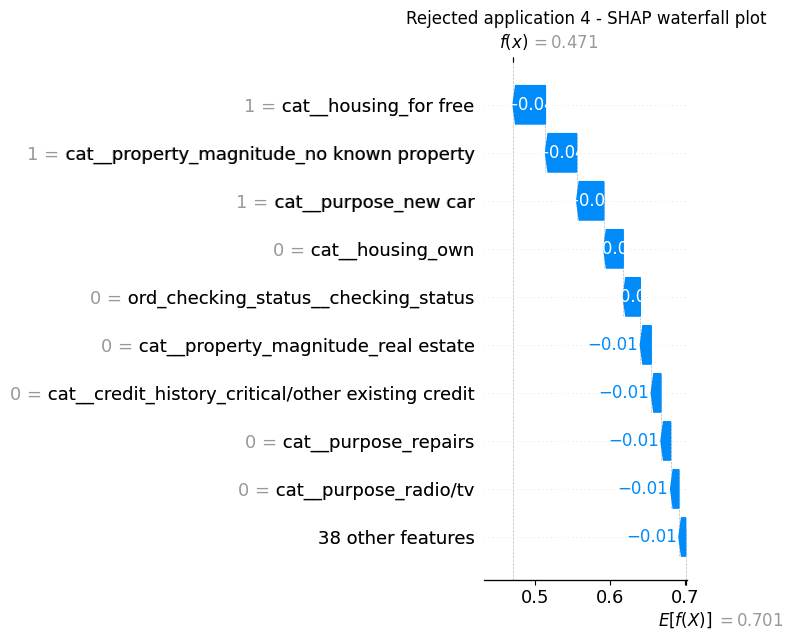

In [74]:
ridx = rejected_apps.index[3]
explanation_i = shap.Explanation(
    values=shap_values_rej[3],
    base_values=expected_value,
    data=X_rej_trans[3],
    feature_names=feature_names_transformed,
)

plt.figure(figsize=(10, 6))
shap.plots.waterfall(explanation_i, max_display=10, show=False)
plt.title(f"Rejected application {ridx} - SHAP waterfall plot")
plt.tight_layout()
plt.show()

All displayed features push the prediction toward the negative class.
Interestingly, the counterfactuals do not suggest changing credit amount this time.
Instead, they suggest other actions such as obtaining a telephone, changing checking status, and modifying employment status (finding a new job). For this case, one counterfactual also recommends moving to no checking account status.

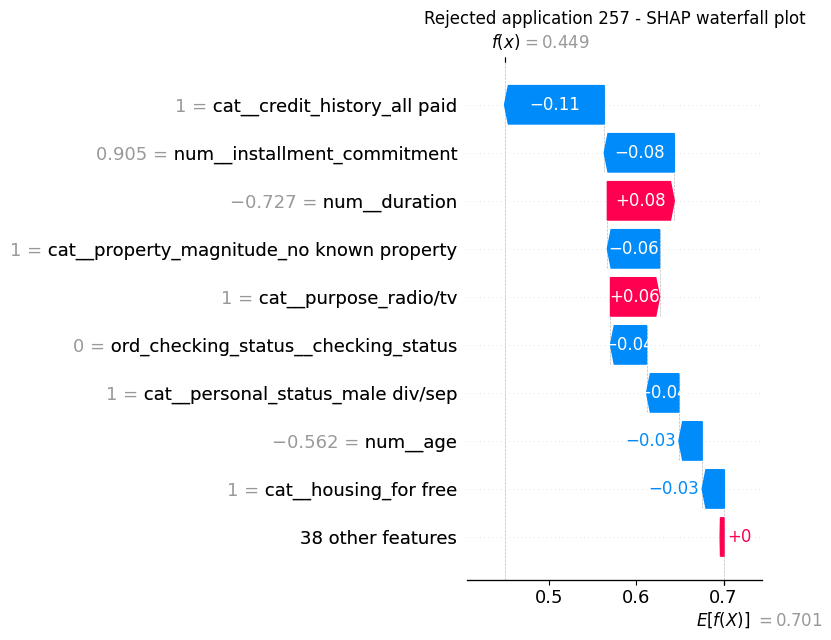

In [75]:
ridx = rejected_apps.index[4]
explanation_i = shap.Explanation(
    values=shap_values_rej[4],
    base_values=expected_value,
    data=X_rej_trans[4],
    feature_names=feature_names_transformed,
)

plt.figure(figsize=(10, 6))
shap.plots.waterfall(explanation_i, max_display=10, show=False)
plt.title(f"Rejected application {ridx} - SHAP waterfall plot")
plt.tight_layout()
plt.show()

In this last example, it is the only case where the remaining features push the prediction toward the positive class.
Surprisingly, a fully paid credit history is one of the strongest contributions toward the negative class, which is counterintuitive.
The suggested paths include modifying credit amount, getting a new job, and obtaining a telephone.
Removing checking account status appears in two counterfactuals.
Two other paths include increasing savings or moving to the high qualif/self emp/mgmt category.

Overall, getting a new job (<1), having your own telephone, and slightly adjusting credit amount were important factors for being accepted, and they were changed whenever feasible.

### Counterfactual vs SHAP comparison and analysis

In [77]:
from collections import Counter

# Helper: map transformed feature names back to original base features
# Example names: num__duration, cat__checking_status_<0, ord_checking_status__checking_status

def shap_sum_by_base_feature(shap_row, transformed_feature_names, base_features):
    out = {f: 0.0 for f in base_features}
    for fname, sval in zip(transformed_feature_names, shap_row):
        base = None

        if fname.startswith("num__"):
            base = fname.replace("num__", "", 1)
        elif fname.startswith("cat__"):
            tail = fname.replace("cat__", "", 1)
            candidates = [f for f in base_features if tail.startswith(f + "_")]
            if len(candidates) > 0:
                base = max(candidates, key=len)
        elif "__" in fname:
            # Handles ordinal-encoded columns like ord_checking_status__checking_status
            tail = fname.split("__", 1)[1]
            if tail in base_features:
                base = tail

        if base in out:
            out[base] += float(sval)
    return out

def changed_feature(orig_value, cf_value):
    # Numeric values: compare with tolerance; categorical values: compare as strings.
    if np.issubdtype(np.asarray([orig_value]).dtype, np.number) and np.issubdtype(np.asarray([cf_value]).dtype, np.number):
        return not np.isclose(float(orig_value), float(cf_value), rtol=1e-9, atol=1e-9)
    return str(orig_value) != str(cf_value)

cf_change_counter = Counter({f: 0 for f in actionable_features})

print("Per-person comparison (counterfactual changes vs SHAP negative drivers):")

for i, ridx in enumerate(rejected_apps.index):
    original = rejected_apps.loc[ridx]
    cfs = counterfactual_results[ridx]["cfs"]

    # Count actionable features changed in generated counterfactuals
    changed_any = set()
    for _, cf_row in cfs.iterrows():
        for f in actionable_features:
            if f in cf_row.index and f in original.index and changed_feature(original[f], cf_row[f]):
                changed_any.add(f)
    for f in changed_any:
        cf_change_counter[f] += 1

    # SHAP: aggregate to base actionable features and take strongest negative pushes
    shap_base = shap_sum_by_base_feature(
        shap_values_rej[i], feature_names_transformed, actionable_features
    )
    strongest_negative = sorted(
        [(k, v) for k, v in shap_base.items() if v < 0],
        key=lambda x: x[1],
    )[:3]

    print(f"\nApplication {ridx}:")
    print(f"  Base p(approval): {mlp_pipeline.predict_proba(original.to_frame().T)[0,1]:.4f}")

    if len(strongest_negative) == 0:
        print("  SHAP strongest negative actionable drivers: none")
    else:
        print("  SHAP strongest negative actionable drivers:")
        for f, v in strongest_negative:
            print(f"    - {f}: {v:.4f}")

    print("  Actionable features changed by at least one CF:", sorted(changed_any))

print("\n=== Aggregate analysis across the 5 rejected applications ===")
print("How often each actionable feature was changed by CFs (person-level count):")
for f in actionable_features:
    print(f"  {f}: {cf_change_counter[f]}/5")

print("\nInterpretation:")
print("1) Features changed frequently by CFs are practical levers the model relies on to flip rejection to approval.")
print("2) If a feature is both a strong negative SHAP driver and frequently changed in CFs, it is a consistent bottleneck.")

Per-person comparison (counterfactual changes vs SHAP negative drivers):

Application 634:
  Base p(approval): 0.4920
  SHAP strongest negative actionable drivers:
    - job: -0.0470
  Actionable features changed by at least one CF: ['credit_amount', 'job', 'savings_status']

Application 633:
  Base p(approval): 0.4912
  SHAP strongest negative actionable drivers:
    - employment: -0.0406
  Actionable features changed by at least one CF: ['credit_amount', 'own_telephone']

Application 194:
  Base p(approval): 0.4867
  SHAP strongest negative actionable drivers:
    - duration: -0.1604
    - installment_commitment: -0.0511
  Actionable features changed by at least one CF: ['credit_amount', 'employment', 'own_telephone']

Application 4:
  Base p(approval): 0.4709
  SHAP strongest negative actionable drivers:
    - checking_status: -0.0228
  Actionable features changed by at least one CF: ['checking_status', 'credit_amount', 'employment', 'own_telephone']

Application 257:
  Base p(appro

## Problem 2.4: Attention Visualization (20 points)
Use a pre-trained BERT model for sentiment analysis:

• Analyze movie reviews from IMDB.

• Visualize attention weights for 5 reviews.

• Identify which words contribute most to sentiment predictions.

• Compare attention patterns for positive vs. negative reviews.

In [33]:
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from datasets import load_dataset
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

ModuleNotFoundError: No module named 'transformers'

### Load dataset and pre-trained BERT model

In [ ]:
# 5 reviews (positive & negative)
dataset = load_dataset("imdb", split="test")
print(dataset)

chosen_reviews = []
positive_count = 0
negative_count = 0
for i, example in enumerate(dataset.shuffle(seed=SEED)):
    if positive_count + negative_count >= 5:
        break
    if example["label"] == 1 and positive_count < 3:
        # print the whole review by breaking it into paragraphs of 150 characters for better readability
        print(f"\nExample {i} - Positive review:")
        for j in range(0, len(example["text"]), 150):
            print(f"{example['text'][j:j+150]}")
        chosen_reviews.append(example)
        positive_count += 1
    elif example["label"] == 0 and negative_count < 3:
        print(f"\nExample {i} - Negative review:")
        for j in range(0, len(example["text"]), 150):
            print(f"{example['text'][j:j+150]}")
        chosen_reviews.append(example)
        negative_count += 1

Dataset({
    features: ['text', 'label'],
    num_rows: 25000
})

Example 0 - Positive review:
<br /><br />When I unsuspectedly rented A Thousand Acres, I thought I was in for an entertaining King Lear story and of course Michelle Pfeiffer was i
n it, so what could go wrong?<br /><br />Very quickly, however, I realized that this story was about A Thousand Other Things besides just Acres. I sta
rted crying and couldn't stop until long after the movie ended. Thank you Jane, Laura and Jocelyn, for bringing us such a wonderfully subtle and compa
ssionate movie! Thank you cast, for being involved and portraying the characters with such depth and gentleness!<br /><br />I recognized the Angry sis
ter; the Runaway sister and the sister in Denial. I recognized the Abusive Husband and why he was there and then the Father, oh oh the Father... all s
uperbly played. I also recognized myself and this movie was an eye-opener, a relief, a chance to face my OWN truth and finally doing something about 

In [ ]:
# Load model
model_name = "distilbert-base-uncased-finetuned-sst-2-english"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, output_attentions=True)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

### Get attention weights and probabilities for 5 reviews


Review 0 - True label: Positive. Predicted class: Positive with confidence 0.9989
Text: <br /><br />When I unsuspectedly rented A Thousand Acres, I thought I was in for an entertaining King Lear story and of course Michelle Pfeiffer was i...
Model predicted probabilities: Negative=0.0011, Positive=0.9989


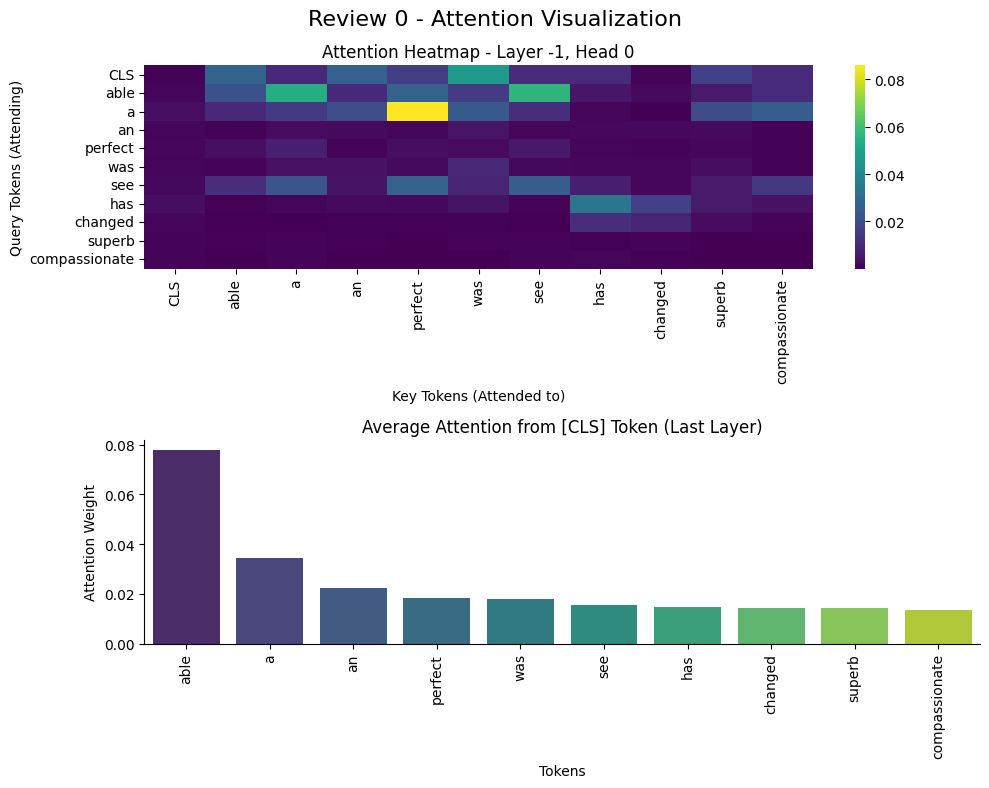


Review 1 - True label: Positive. Predicted class: Positive with confidence 0.9970
Text: This is the latest entry in the long series of films with the French agent, O.S.S. 117 (the French answer to James Bond). The series was launched in t...
Model predicted probabilities: Negative=0.0030, Positive=0.9970


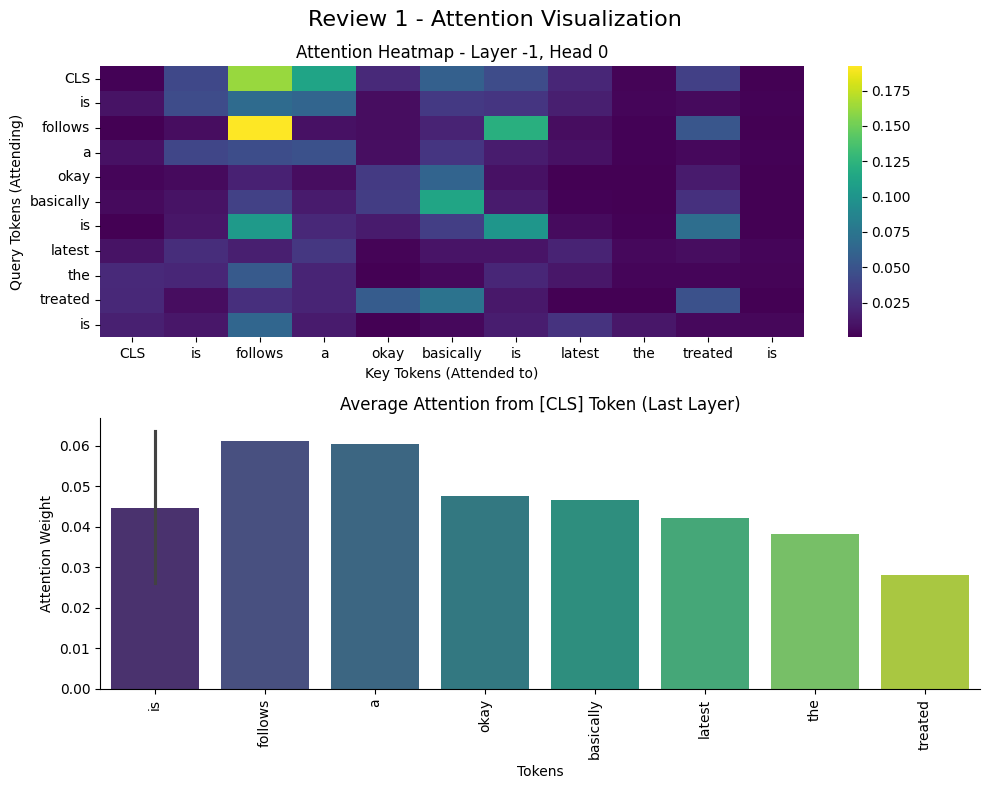


Review 2 - True label: Negative. Predicted class: Negative with confidence 0.9972
Text: This movie was so frustrating. Everything seemed energetic and I was totally prepared to have a good time. I at least thought I'd be able to stand it....
Model predicted probabilities: Negative=0.9972, Positive=0.0028


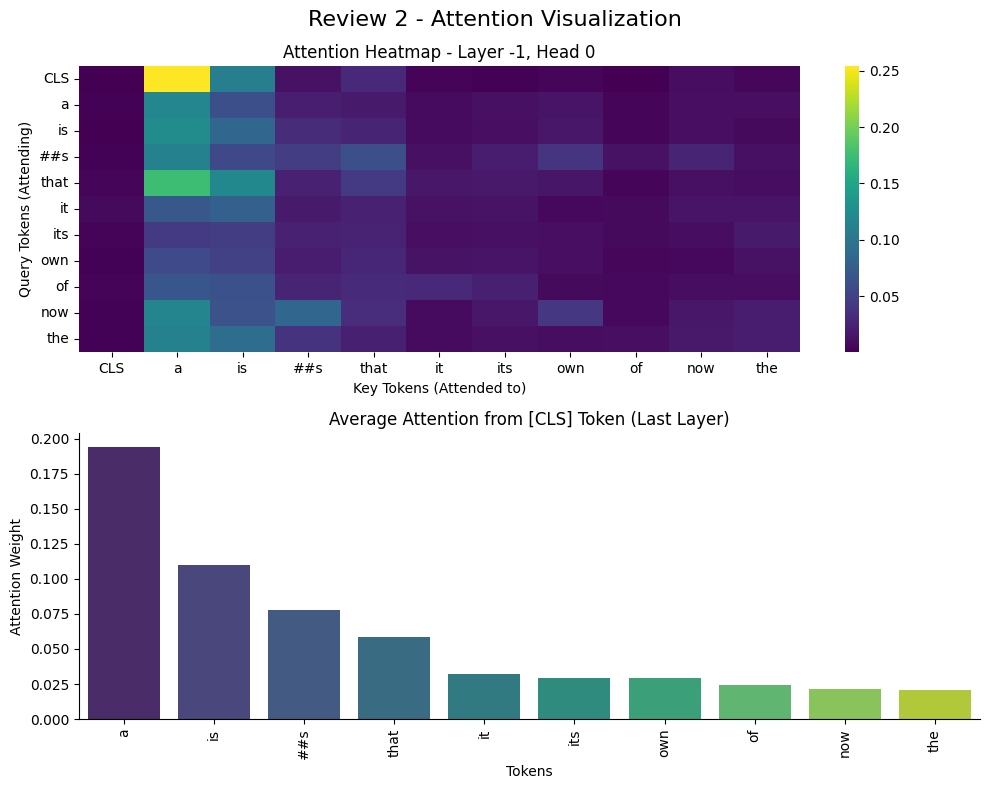


Review 3 - True label: Positive. Predicted class: Negative with confidence 0.6492
Text: I was truly and wonderfully surprised at "O' Brother, Where Art Thou?" The video store was out of all the movies I was planning on renting, so then I ...
Model predicted probabilities: Negative=0.6492, Positive=0.3508


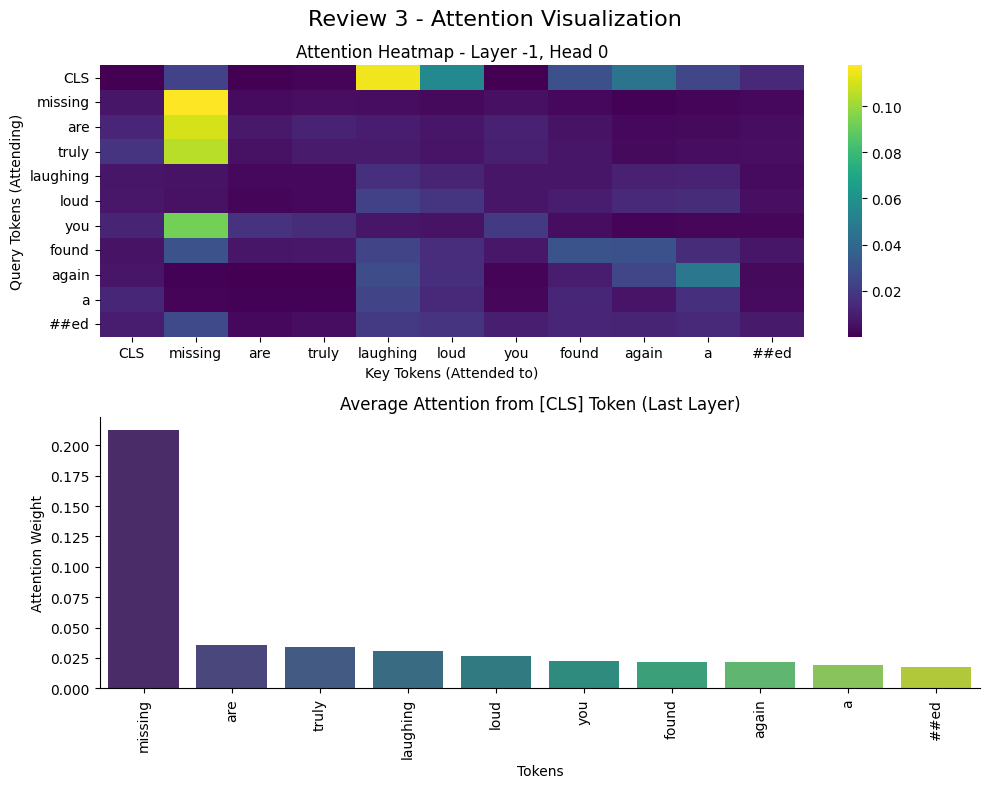


Review 4 - True label: Negative. Predicted class: Negative with confidence 0.9985
Text: This movie spends most of its time preaching that it is the script that makes the movie, but apparently there was no script when they shot this waste ...
Model predicted probabilities: Negative=0.9985, Positive=0.0015


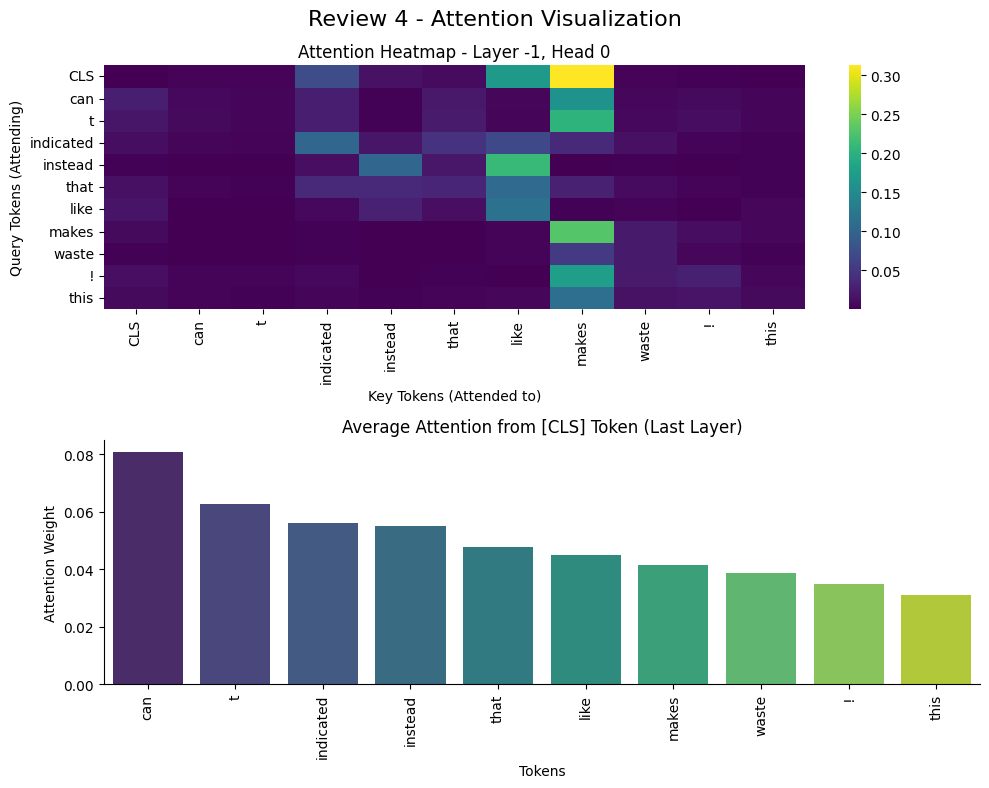

In [ ]:
def predict(texts):
    # Tokenize and encode the input texts, ensuring they fit the model's maximum input length
    inputs = tokenizer(texts, return_tensors="pt", padding=True, truncation=True, max_length=512)  
    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])  # Get tokens for the first input 
    with torch.no_grad():
        outputs = model(**inputs)
        attentions = outputs.attentions  # List of attention tensors from each layer
        probs = F.softmax(outputs.logits, dim=1).cpu().numpy()
    return probs, tokens, attentions

def visualize_attention(text, attentions, tokens, layer=-1, head=0):
    fig, ax = plt.subplots(figsize=(10, 8), nrows=2)

    attention_matrix = attentions[layer][0, head].cpu().numpy()  # Shape: (seq_len, seq_len)

    last_layer = attentions[layer][head]
    avg_attention = last_layer.mean(dim=0).cpu().numpy()  # Average over heads
    cls_attention = avg_attention[0]  # Attention from [CLS] token to all tokens

    top_indices = np.argsort(cls_attention)[-10:][::-1]  # Get indices of top 10 attended tokens
    top_tokens = [tokens[i] for i in top_indices]
    top_attention = cls_attention[top_indices]

    # Focus the attention matrix on the top tokens and CLS for better visualization
    attention_matrix = attention_matrix[np.ix_(np.r_[[0], top_indices], np.r_[[0], top_indices])]

    sns.heatmap(attention_matrix, xticklabels=["CLS"] + top_tokens, yticklabels=["CLS"] + top_tokens, cmap="viridis", ax=ax[0])
    ax[0].set_title(f"Attention Heatmap - Layer {layer}, Head {head}")
    ax[0].set_xlabel("Key Tokens (Attended to)")
    ax[0].set_ylabel("Query Tokens (Attending)")

    sns.barplot(x=top_tokens, y=top_attention, ax=ax[1], palette="viridis")
    ax[1].set_title("Average Attention from [CLS] Token (Last Layer)")
    ax[1].set_xlabel("Tokens")
    ax[1].set_ylabel("Attention Weight")
    # hide frame 
    ax[1].spines['top'].set_visible(False)
    ax[1].spines['right'].set_visible(False)
    plt.xticks(rotation=90)
    
    return fig

for i, ex in enumerate(chosen_reviews):
    probs, tokens, attentions = predict(ex["text"])
    print(f"\nReview {i} - True label: {'Positive' if ex['label'] == 1 else 'Negative'}. Predicted class: {'Positive' if np.argmax(probs) == 1 else 'Negative'} with confidence {probs[0][np.argmax(probs)]:.4f}")
    print(f"Text: {ex['text'][:150]}...")
    print(f"Model predicted probabilities: Negative={probs[0][0]:.4f}, Positive={probs[0][1]:.4f}")

    fig = visualize_attention(ex['text'], attentions, tokens)
    plt.suptitle(f"Review {i} - Attention Visualization", fontsize=16)
    plt.tight_layout()
    plt.show()

Review 0 is predicted as positive. The model attends most to able, perfect, superb, and compassionate—the strong sentiment markers that drive the prediction. Other tokens are much less influential.

Review 1 sounds neutral to a human reader, but the model classifies it as positive. The top-attended words are mundane structural terms—is, follows, a, okay. Yet the model detects positive sentiment in this seemingly neutral text.

Review 2 is clearly negative, and the model classifies it with high confidence. The strongest attention goes to basic tokens such as a, is, ##s, that, and it, which are not the words a human would usually treat as indicators. In contrast, a human reader would focus more on stronger words such as hated or crappy, while the model still captures the overall sentiment and predicts the review as negative.

Review 3 is the only example where the model gets the sentiment wrong, and even then with low confidence. To a human reader, the opinion is clearly positive. The token missing has a fairly high attention weight and can be read as a negative cue, while laughing can be interpreted as a positive cue. In this case, it may be necessary to read a larger part of the text to understand the positive meaning of the review.

Review 4 is clearly negative, and the model catches that with ease. High attention is given to tokens such as instead and waste, which help carry the negative tone of the review.